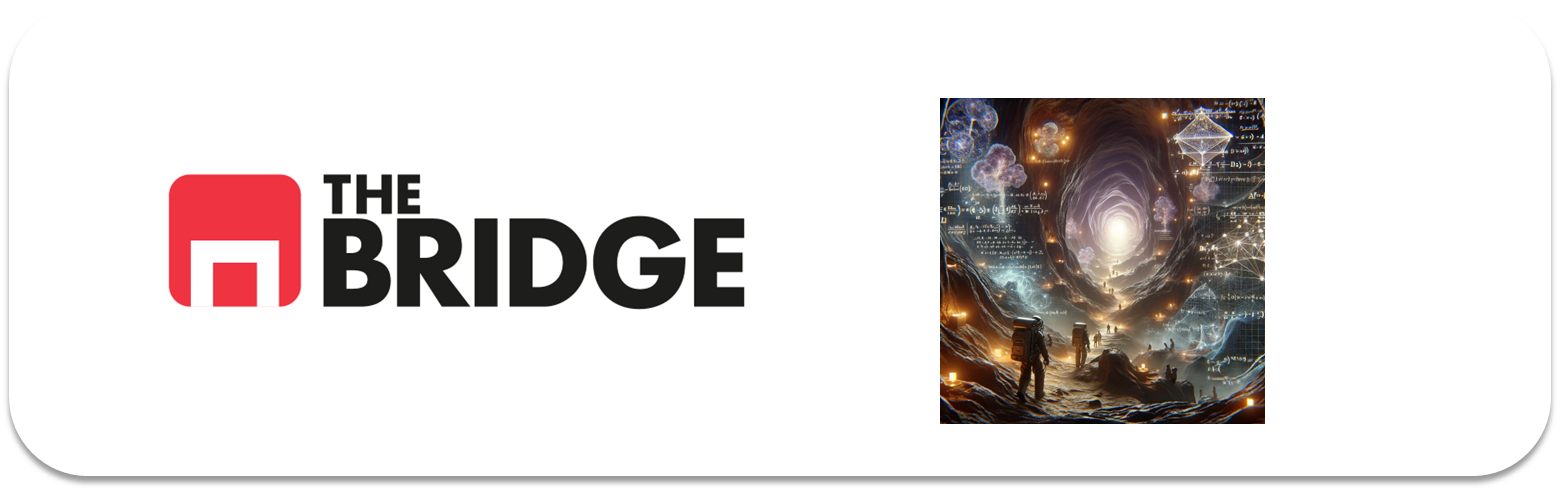

## PRACTICA OBLIGATORIA: **Introducción Deep Learning**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de modelado del dataset del titanic empleando y comparando dos modelos diferentes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# Tratamiento de datos
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Utilidades de visualización del bootcamp (está en la misma carpeta que el notebook)
import bootcampviztools as bvt

# Modelado
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# Semilla única para todo el notebook, así los resultados son reproducibles
SEED = 42

# El MLP avisa de "no convergencia" con frecuencia; silenciamos para no ensuciar la salida
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

print("Librerías importadas correctamente")

Librerías importadas correctamente


### Descripción y objetivo

El objetivo de la práctica es crear un modelo DL y compararlo con un modelo Random Forest para el dataset de titanic los dos con el mismo objetivo, predecir la supervivencia de un pasajero.  Se pide:  
1. Desarrollar el proceso de ML hasta crear los dos modelos DL y Random Forest. El primero debe tener una topología MLP (es decir una red densa) con un máximo de 3 capas ocultas y debes emplear sklearn para crearlo. No es necesario hacer una análisis/seleccion exahustivo. Escoge una métrica acorde al tipo de target del problema. 

2. Ambos modelos deben tener sus hiperparámetros optimizados, mediante GridSearch. Para ello: utiliza el grid de parámetros que creas conveniente para Random Forest y para el modelo DL, utiliza un grid con los hiperparámetros siguientes:'hidden_layer_sizes','activation', 'solver','alpha' y 'learning_rate'. Para los rangos del grid del modelo de DL guíate por lo visto en el workout y por los posibles valores que se indican en la [documentación](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier). Prueba por lo menos una topología con una sola capa oculta y otra con más de una capa oculta.   
NOTA: Incluye los valores por defecto de los hiperparámetros escogidos en cada caso dentro del grid de hiperparámetros. 
  

3. Compara los modelos respecto a sus métricas medias de accuracy, precision, recall y tiempos de entrenamiento (para ello tendrás que realizar un entrenamiento a parte del mejor modelo obtenido en la optimización de hiperparámetros) y decide cuál te quedarías argumentándolo.    

4. Para el mejor modelo DL obtenido, muestra su clasification report, y la matriz de confusión comentando el resultado.


---
## 1. Carga de datos y análisis exploratorio

Empezamos cargando el dataset y echando un primer vistazo. El enunciado dice que **no hace falta un
análisis exhaustivo**, así que nos centraremos en lo imprescindible para poder modelar: entender las
columnas, detectar nulos y decidir con qué features nos quedamos.

In [2]:
# Cargamos los datos
df = pd.read_csv("./data/titanic.csv")

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Tipos de dato y nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [4]:
# Contamos los nulos de cada columna, en absoluto y en porcentaje
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje": (df.isna().sum() / len(df) * 100).round(2),
})
nulos[nulos["nulos"] > 0]

,nulos,porcentaje
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


**Nulos detectados:**

- **`deck`**: 688 de 891 nulos (**77%**). Con esa cantidad de huecos no merece la pena intentar
  imputarla, la descartaremos.
- **`age`**: 177 nulos (~20%). Es una variable importante para predecir la supervivencia
  ("las mujeres y los niños primero"), así que **la imputaremos** en lugar de tirarla.
- **`embarked`**: solo 2 nulos. Los rellenamos con la moda y listo.

In [5]:
# Cardinalidad de cada columna: nos ayuda a detectar duplicados y variables poco útiles
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "valores_unicos": df.nunique(),
    "ejemplos": [list(df[c].dropna().unique()[:4]) for c in df.columns],
})
resumen

,tipo,valores_unicos,ejemplos
survived,int64,2,"[0, 1]"
pclass,int64,3,"[3, 1, 2]"
sex,str,2,"[male, female]"
age,float64,88,"[22.0, 38.0, 26.0, 35.0]"
sibsp,int64,7,"[1, 0, 3, 4]"
parch,int64,7,"[0, 1, 2, 5]"
fare,float64,248,"[7.25, 71.2833, 7.925, 53.1]"
embarked,str,3,"[S, C, Q]"
class,str,3,"[Third, First, Second]"
who,str,3,"[man, woman, child]"


### Cuidado: hay una fuga de datos (*data leakage*)

Al mirar la cardinalidad salta algo importante: la columna **`alive`** toma los valores `"yes"`/`"no"`
y **es exactamente el mismo dato que el target `survived`**, solo que escrito como texto. Vamos a
comprobarlo.

In [6]:
# Comprobamos que "alive" es literalmente el target disfrazado de texto
print(pd.crosstab(df["survived"], df["alive"]))

alive      no  yes
survived          
0         549    0
1           0  342


Confirmado: la tabla es perfectamente diagonal. **`alive` es el target**.

Si dejásemos esta columna entre las features, los dos modelos alcanzarían un **100% de acierto**...
pero sería un resultado completamente falso, porque en un caso real no dispondríamos de ese dato en
el momento de predecir (si ya sabemos si el pasajero está vivo, no necesitamos ningún modelo). Esto
es un caso de libro de **data leakage**, y hay que eliminar la columna sí o sí.

Además hay varias columnas **redundantes**, que son la misma información repetida de otra forma:

| Columna | Motivo para descartarla |
|---|---|
| `alive` | **Fuga de datos**: es el target en texto |
| `class` | Es `pclass` escrito en texto (`First`/`Second`/`Third`) |
| `embark_town` | Es `embarked` con el nombre completo del puerto |
| `who` | Se deriva de `sex` + `age` (`man`/`woman`/`child`) |
| `adult_male` | Se deriva también de `sex` + `age` |
| `deck` | 77% de nulos |

Mantener columnas duplicadas no rompe el modelo, pero añade ruido y complica la interpretación, así
que nos quedamos con una sola versión de cada cosa.

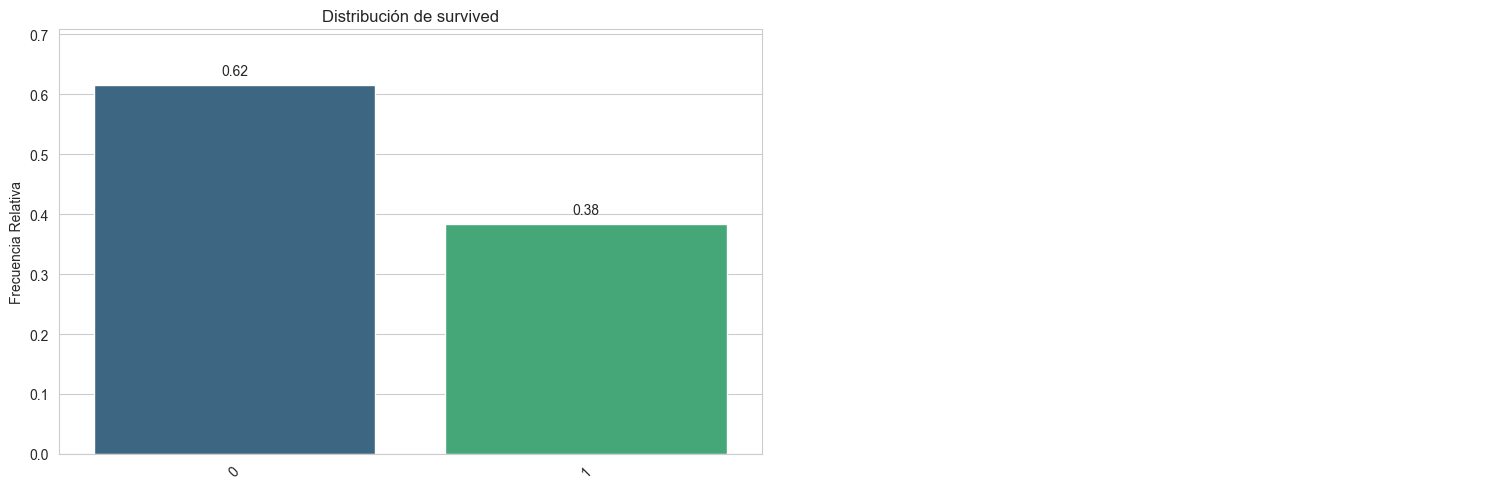

survived
0    549
1    342
Name: count, dtype: int64

survived
0    0.6162
1    0.3838
Name: proportion, dtype: float64


In [7]:
# Analizamos el target: es lo primero que hay que mirar siempre en clasificación
bvt.pinta_distribucion_categoricas(df, ["survived"], relativa=True, mostrar_valores=True)

print(df["survived"].value_counts())
print()
print(df["survived"].value_counts(normalize=True).round(4))

**Análisis del target:** sobrevivió el **38,4%** de los pasajeros frente a un **61,6%** que no.

Hay cierto desbalanceo, pero es **moderado** (no estamos en un caso extremo tipo 95/5). Volveremos
sobre esto al elegir la métrica.

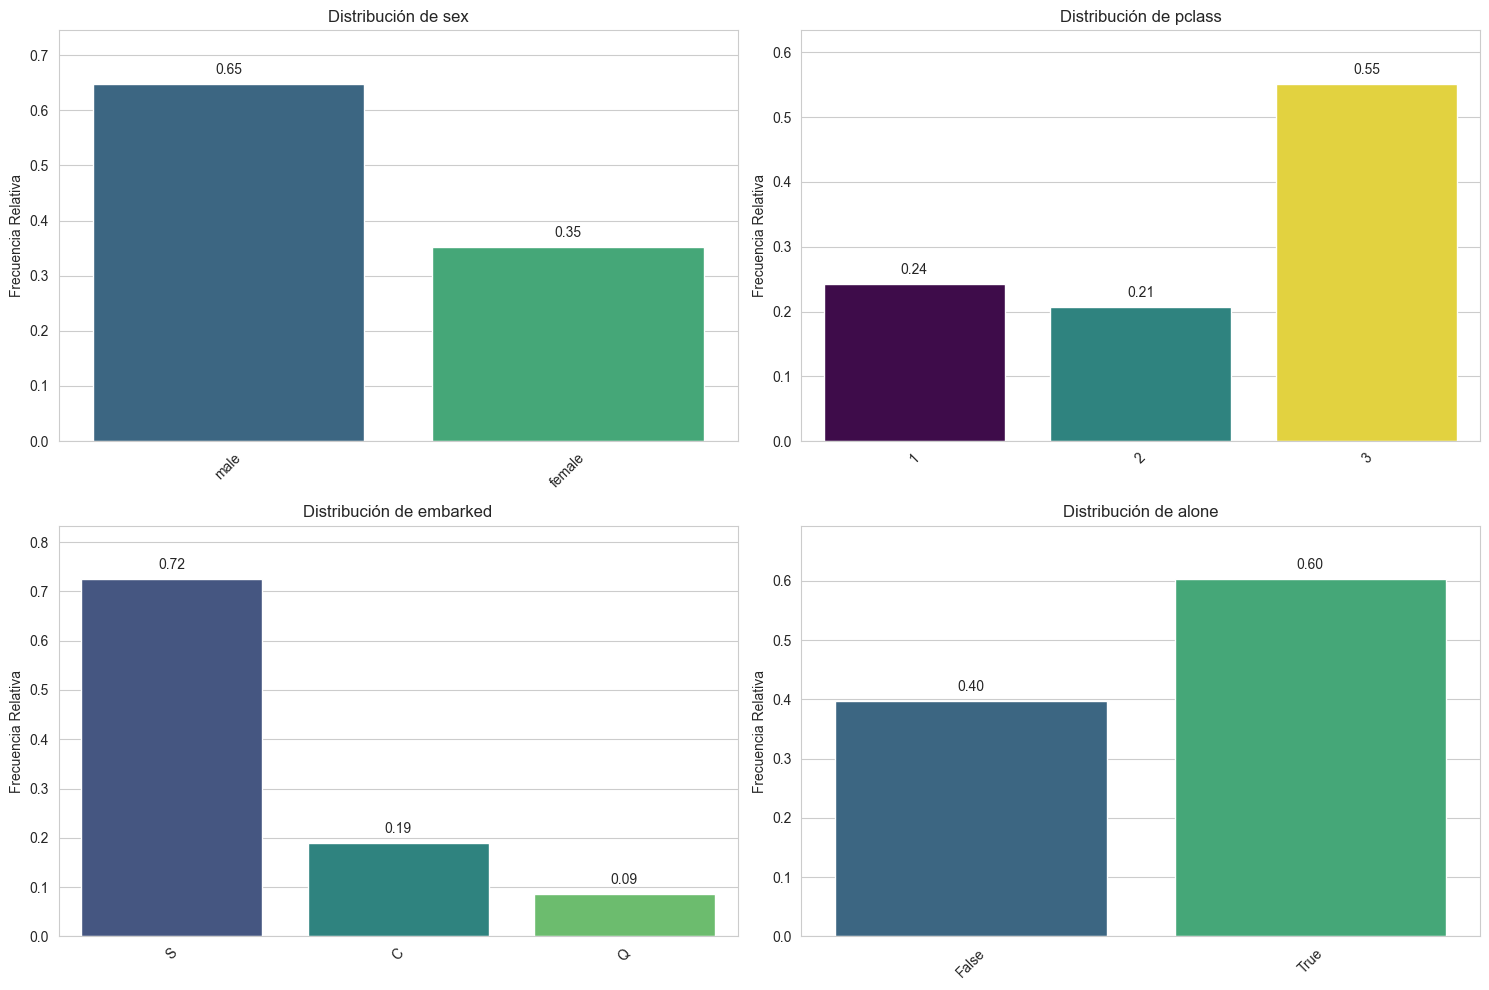

In [8]:
# Distribución de las principales variables categóricas
bvt.pinta_distribucion_categoricas(
    df,
    ["sex", "pclass", "embarked", "alone"],
    relativa=True,
    mostrar_valores=True,
)

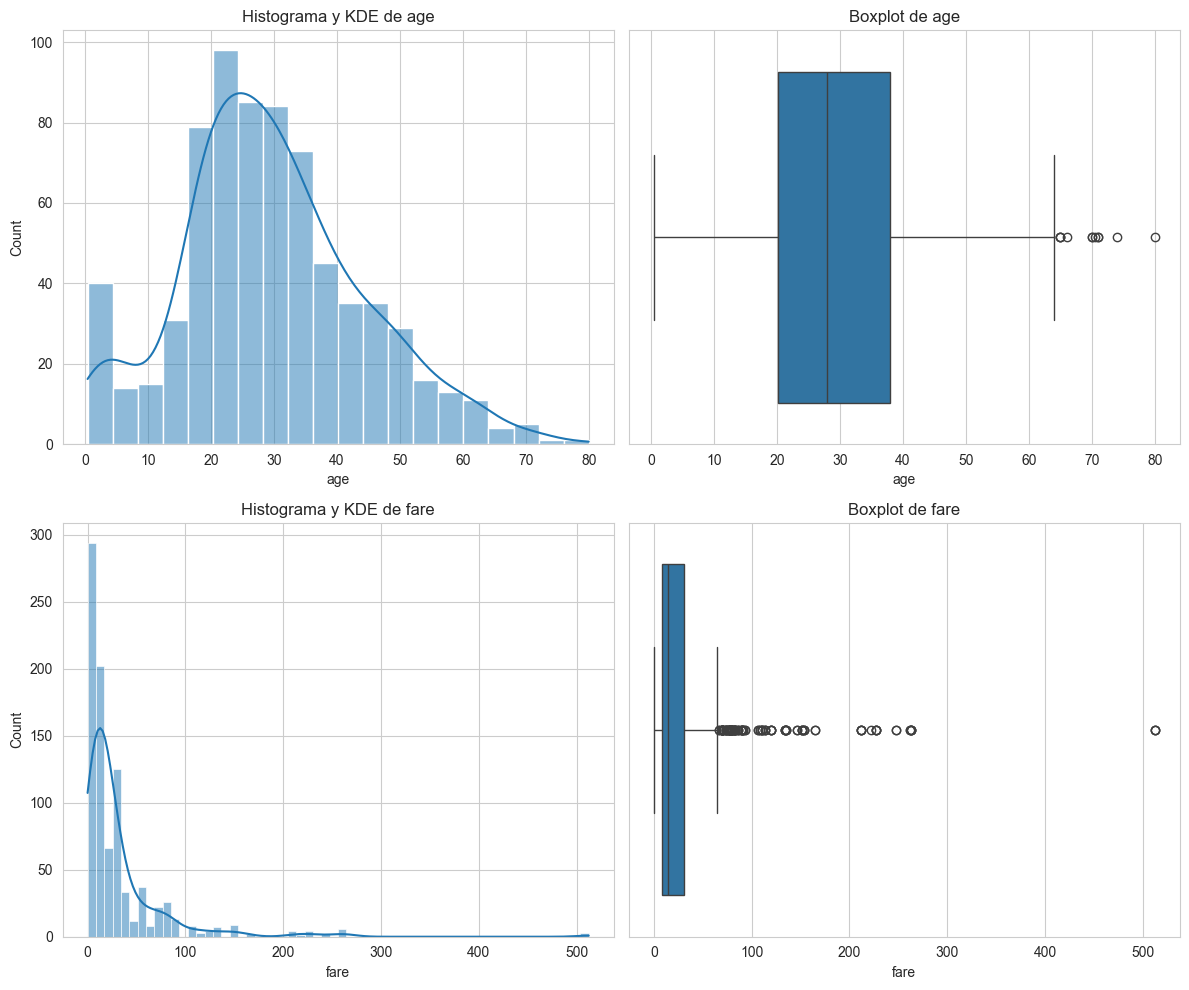

In [9]:
# Distribución de las variables numéricas continuas
bvt.plot_combined_graphs(df, ["age", "fare"])

- **`age`**: se concentra entre los 20 y los 40 años, con una distribución bastante normal.
- **`fare`**: muy asimétrica a la derecha, con outliers muy marcados (billetes de primera clase que
  costaron muchísimo más que la media).

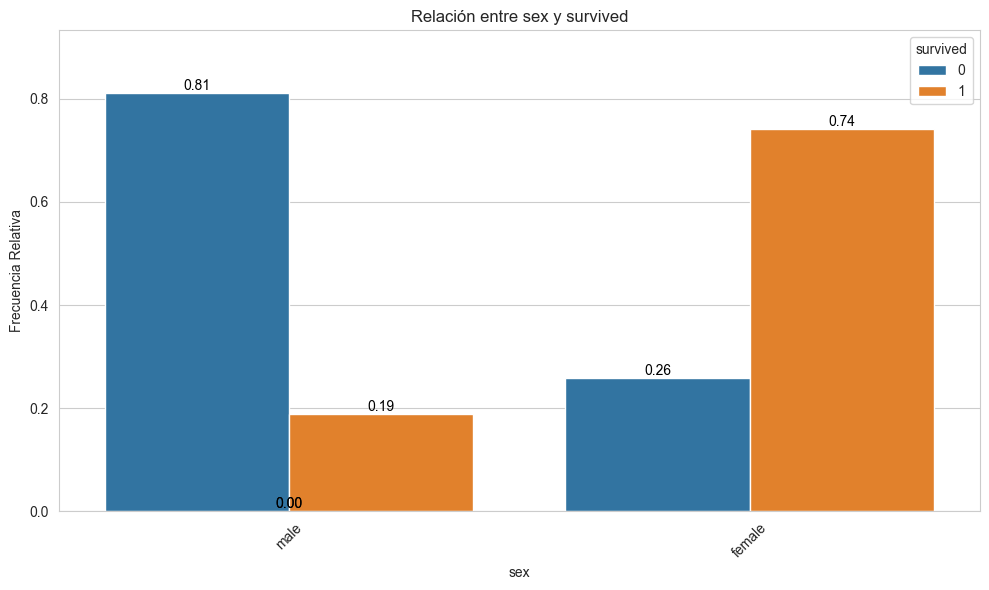

In [10]:
# Relación entre el sexo y la supervivencia: la variable más determinante del dataset
bvt.plot_categorical_relationship(df, "sex", "survived", relative_freq=True, show_values=True)

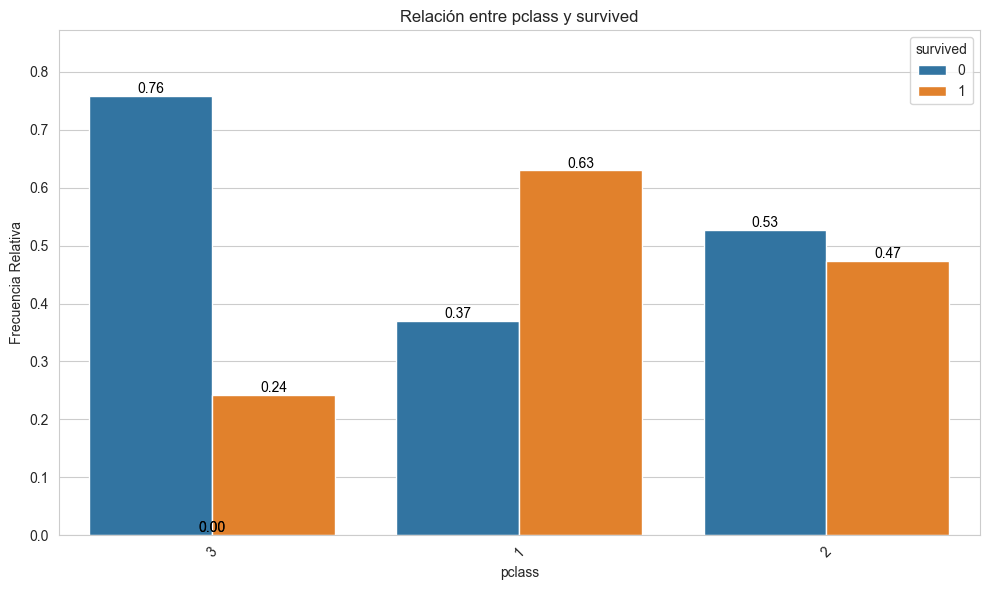

In [11]:
# Relación entre la clase del billete y la supervivencia
bvt.plot_categorical_relationship(df, "pclass", "survived", relative_freq=True, show_values=True)

**Conclusiones del EDA:**

- El **sexo** es con diferencia la variable más predictiva: sobrevivió alrededor del **74% de las
  mujeres** frente a solo un **19% de los hombres**. Encaja perfectamente con el protocolo
  "las mujeres y los niños primero".
- La **clase del billete** también pesa mucho: en primera clase sobrevivió en torno al **63%**,
  mientras que en tercera apenas el **24%**.

Ambas variables tienen una relación clara con el target, así que las mantenemos en el modelo.

---
## 2. Preprocesado de los datos

Aplicamos lo que hemos decidido en el EDA: eliminar columnas problemáticas, imputar nulos y
codificar las categóricas a números (los modelos de sklearn no admiten texto).

In [12]:
# Trabajamos sobre una copia para no tocar el dataframe original
df_modelo = df.copy()

# 1) Eliminamos las columnas con fuga de datos, redundantes o con demasiados nulos
columnas_a_eliminar = [
    "alive",         # FUGA DE DATOS: es el target en texto
    "class",         # duplicado de pclass
    "embark_town",   # duplicado de embarked
    "who",           # derivada de sex + age
    "adult_male",    # derivada de sex + age
    "deck",          # 77% de nulos
]
df_modelo = df_modelo.drop(columns=columnas_a_eliminar)

print("Columnas eliminadas:", columnas_a_eliminar)
print("Columnas restantes :", df_modelo.columns.tolist())

Columnas eliminadas: ['alive', 'class', 'embark_town', 'who', 'adult_male', 'deck']
Columnas restantes : ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']


In [13]:
# 2) Imputamos los nulos
#    - age: usamos la MEDIANA porque es robusta frente a outliers
#    - embarked: usamos la MODA (el puerto más frecuente), solo son 2 valores
mediana_age = df_modelo["age"].median()
moda_embarked = df_modelo["embarked"].mode()[0]

df_modelo["age"] = df_modelo["age"].fillna(mediana_age)
df_modelo["embarked"] = df_modelo["embarked"].fillna(moda_embarked)

print("Mediana de age usada para imputar:", mediana_age)
print("Moda de embarked usada para imputar:", moda_embarked)
print("\nNulos restantes:", df_modelo.isna().sum().sum())

Mediana de age usada para imputar: 28.0
Moda de embarked usada para imputar: S

Nulos restantes: 0


In [14]:
# 3) Codificamos las variables categóricas
#    - sex: solo tiene 2 valores, lo mapeamos directamente a 0/1
#    - alone: es booleano (True/False), lo pasamos a entero
#    - embarked: tiene 3 valores sin orden natural -> one-hot encoding
df_modelo["sex"] = df_modelo["sex"].map({"male": 0, "female": 1})
df_modelo["alone"] = df_modelo["alone"].astype(int)

df_modelo = pd.get_dummies(df_modelo, columns=["embarked"], drop_first=True, dtype=int)

print("Dataset final para el modelado:", df_modelo.shape)
df_modelo.head()

Dataset final para el modelado: (891, 10)


,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,1,26.0,0,0,7.9250,1,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,1,0,1


> **¿Por qué `drop_first=True`?** Con 3 puertos (`C`, `Q`, `S`) bastan 2 columnas para
> representarlos: si `embarked_Q` y `embarked_S` valen 0, sabemos que el pasajero embarcó en `C`.
> Así evitamos introducir una columna redundante.

In [15]:
# 4) Separamos features (X) y target (y), y hacemos el split en train y test
X = df_modelo.drop(columns="survived")
y = df_modelo["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,   # mantiene la proporción de supervivientes en train y test
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)
print("\nProporción de supervivientes en train:", round(y_train.mean(), 4))
print("Proporción de supervivientes en test :", round(y_test.mean(), 4))

X_train: (712, 9) | y_train: (712,)
X_test : (179, 9) | y_test : (179,)

Proporción de supervivientes en train: 0.3834
Proporción de supervivientes en test : 0.3855


---
## 3. Elección de la métrica

El enunciado pide **escoger una métrica acorde al tipo de target**. Nuestro target es
**binario** (sobrevivió / no sobrevivió) y está **moderadamente desbalanceado**: 61,6% frente a 38,4%.

**Métrica elegida: `accuracy`**, por estos motivos:

1. El desbalanceo es moderado. Con un 62/38 el accuracy sigue siendo informativo. Sería mala idea con
   un 95/5, donde un modelo que prediga siempre la clase mayoritaria ya sacaría un 95% sin haber
   aprendido nada.
2. En este problema **los dos tipos de error nos importan por igual**: no hay ninguna razón de negocio
   para preferir equivocarnos en un sentido o en otro (a diferencia, por ejemplo, de un diagnóstico
   médico, donde un falso negativo es mucho más grave).
3. Es la métrica más fácil de interpretar y de comparar entre modelos.

Aun así, el enunciado nos pide comparar también **precision** y **recall**, así que las calcularemos
todas y las miraremos en conjunto. El accuracy será lo que optimice el `GridSearchCV`.

---
## 4. Modelo de Deep Learning: MLP con GridSearch

Construimos el modelo DL con **`MLPClassifier` de sklearn**, con un máximo de **3 capas ocultas**
como pide el enunciado.

Lo metemos dentro de un **`Pipeline` junto al `StandardScaler`**. Esto es importante: como vimos en
el workout, las redes neuronales entrenan por descenso del gradiente y son **muy sensibles a la
escala**. Al meter el escalado dentro del pipeline nos aseguramos de que, en la validación cruzada,
el scaler se ajuste **solo con los datos de entrenamiento de cada fold** y nunca con los de
validación. Si escalásemos antes del GridSearch estaríamos filtrando información entre folds
(*data leakage*).

In [16]:
# Pipeline: primero escala, luego entrena la red
pipe_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(max_iter=1000, random_state=SEED)),
])

# Grid con los 5 hiperparámetros que pide el enunciado.
# El prefijo "mlp__" indica que el hiperparámetro es del paso "mlp" del pipeline.
# NOTA: incluimos los valores POR DEFECTO de cada hiperparámetro, como pide el enunciado:
#   hidden_layer_sizes=(100,), activation="relu", solver="adam",
#   alpha=0.0001, learning_rate="constant"
param_grid_mlp = {
    # 4 topologías: 2 con UNA capa oculta y 2 con VARIAS (máximo 3, como pide el enunciado)
    "mlp__hidden_layer_sizes": [(100,), (50,), (50, 50), (100, 50, 25)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__solver": ["adam", "sgd"],
    "mlp__alpha": [0.0001, 0.001, 0.01],
    "mlp__learning_rate": ["constant", "adaptive"],
}

# Calculamos cuántas combinaciones vamos a probar
total = 1
for valores in param_grid_mlp.values():
    total *= len(valores)
print("Combinaciones a probar:", total, "| con cv=5 son", total * 5, "entrenamientos")

Combinaciones a probar: 96 | con cv=5 son 480 entrenamientos


> **Detalle a tener en cuenta:** el hiperparámetro `learning_rate` **solo tiene efecto cuando
> `solver="sgd"`**. Con `solver="adam"` sklearn lo ignora, porque Adam ajusta el learning rate por su
> cuenta de forma adaptativa. Esto significa que parte de las combinaciones del grid son en realidad
> equivalentes entre sí y estamos repitiendo trabajo. Lo mantenemos porque el enunciado pide
> expresamente incluir `learning_rate`, pero conviene saber que ocurre.

In [17]:
# Lanzamos el GridSearch. n_jobs=-1 usa todos los núcleos disponibles para ir más rápido.
grid_mlp = GridSearchCV(
    pipe_mlp,
    param_grid_mlp,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

inicio = time.time()
grid_mlp.fit(X_train, y_train)
tiempo_grid_mlp = time.time() - inicio

print("Tiempo total del GridSearch: {:.1f} s".format(tiempo_grid_mlp))
print("\nMejores hiperparámetros encontrados:")
for parametro, valor in grid_mlp.best_params_.items():
    print("  {}: {}".format(parametro, valor))
print("\nMejor accuracy en validación cruzada: {:.4f}".format(grid_mlp.best_score_))

Tiempo total del GridSearch: 99.9 s

Mejores hiperparámetros encontrados:
  mlp__activation: relu
  mlp__alpha: 0.01
  mlp__hidden_layer_sizes: (100,)
  mlp__learning_rate: constant
  mlp__solver: adam

Mejor accuracy en validación cruzada: 0.8174


In [18]:
# Vemos las 10 mejores combinaciones para hacernos una idea de cuánto influye cada hiperparámetro
resultados_mlp = pd.DataFrame(grid_mlp.cv_results_)
columnas = [
    "param_mlp__hidden_layer_sizes", "param_mlp__activation", "param_mlp__solver",
    "param_mlp__alpha", "param_mlp__learning_rate", "mean_test_score", "std_test_score",
]
resultados_mlp[columnas].sort_values("mean_test_score", ascending=False).head(10)

,param_mlp__hidden_layer_sizes,param_mlp__activation,param_mlp__solver,param_mlp__alpha,param_mlp__learning_rate,mean_test_score,std_test_score
34,"(100,)",relu,adam,0.0100,adaptive,0.817423,0.025520
32,"(100,)",relu,adam,0.0100,constant,0.817423,0.025520
54,"(50,)",tanh,adam,0.0001,adaptive,0.816025,0.024846
52,"(50,)",tanh,adam,0.0001,constant,0.816025,0.024846
70,"(50,)",tanh,adam,0.0010,adaptive,0.816025,0.024846
68,"(50,)",tanh,adam,0.0010,constant,0.816025,0.024846
20,"(50,)",relu,adam,0.0010,constant,0.814646,0.023465
22,"(50,)",relu,adam,0.0010,adaptive,0.814646,0.023465
36,"(50,)",relu,adam,0.0100,constant,0.814636,0.025172
38,"(50,)",relu,adam,0.0100,adaptive,0.814636,0.025172


---
## 5. Modelo Random Forest con GridSearch

Ahora el modelo con el que vamos a comparar. Aquí **no hace falta escalar**: el Random Forest se basa
en árboles de decisión, que funcionan haciendo cortes del tipo "age > 30", y esos cortes no cambian
aunque cambiemos la escala de la variable. Es una de las ventajas prácticas de los modelos de árboles
frente a las redes neuronales.

In [19]:
rf = RandomForestClassifier(random_state=SEED)

# Grid de hiperparámetros para el Random Forest.
# Igual que antes, incluimos los valores por defecto:
#   n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

total_rf = 1
for valores in param_grid_rf.values():
    total_rf *= len(valores)
print("Combinaciones a probar:", total_rf, "| con cv=5 son", total_rf * 5, "entrenamientos")

Combinaciones a probar: 24 | con cv=5 son 120 entrenamientos


In [20]:
grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

inicio = time.time()
grid_rf.fit(X_train, y_train)
tiempo_grid_rf = time.time() - inicio

print("Tiempo total del GridSearch: {:.1f} s".format(tiempo_grid_rf))
print("\nMejores hiperparámetros encontrados:")
for parametro, valor in grid_rf.best_params_.items():
    print("  {}: {}".format(parametro, valor))
print("\nMejor accuracy en validación cruzada: {:.4f}".format(grid_rf.best_score_))

Tiempo total del GridSearch: 4.1 s

Mejores hiperparámetros encontrados:
  max_depth: 5
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 200

Mejor accuracy en validación cruzada: 0.8274


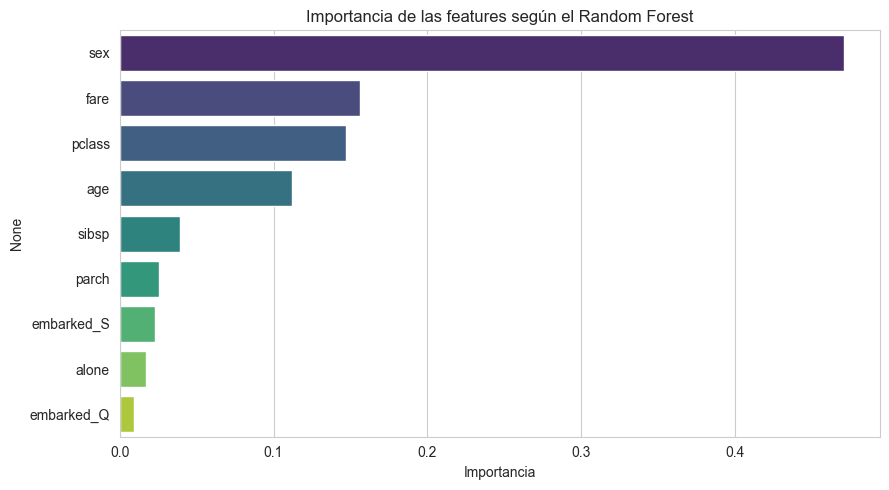

sex           0.4706
fare          0.1564
pclass        0.1474
age           0.1120
sibsp         0.0393
parch         0.0253
embarked_S    0.0228
alone         0.0172
embarked_Q    0.0090
dtype: float64


In [21]:
# Como el Random Forest sí es interpretable, aprovechamos para ver qué features considera importantes
importancias = pd.Series(
    grid_rf.best_estimator_.feature_importances_,
    index=X_train.columns,
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=importancias.values, y=importancias.index, hue=importancias.index,
            palette="viridis", legend=False)
plt.title("Importancia de las features según el Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

print(importancias.round(4))

Las features más importantes coinciden con lo que habíamos visto en el EDA: **el sexo domina con
diferencia**, seguido de la tarifa (`fare`), la edad (`age`) y la clase (`pclass`). Es una buena
señal de que el modelo está aprendiendo patrones reales y no ruido.

---
## 6. Comparación de los dos modelos

El enunciado pide comparar **accuracy, precision, recall y tiempos de entrenamiento**, y para medir
bien los tiempos hay que hacer **un entrenamiento aparte del mejor modelo** de cada tipo (el tiempo
del GridSearch completo no vale, porque incluye cientos de entrenamientos).

Creamos una función auxiliar para no repetir código y medir exactamente igual en ambos casos.

In [22]:
def evalua_modelo(modelo, nombre, X_train, y_train, X_test, y_test):
    """
    Reentrena desde cero el modelo indicado, mide sus tiempos y calcula sus métricas.

    Argumentos:
        modelo: estimador de sklearn ya configurado con los mejores hiperparámetros.
        nombre (str): nombre del modelo, para identificarlo en la tabla.
        X_train, y_train: datos de entrenamiento.
        X_test, y_test: datos de prueba.

    Retorna:
        dict: métricas y tiempos del modelo.
    """
    # Tiempo de ENTRENAMIENTO (entrenamiento aparte, como pide el enunciado)
    inicio = time.time()
    modelo.fit(X_train, y_train)
    t_entrenamiento = time.time() - inicio

    # Tiempo de PREDICCIÓN
    inicio = time.time()
    y_pred = modelo.predict(X_test)
    t_prediccion = time.time() - inicio

    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "t_entrenamiento_s": t_entrenamiento,
        "t_prediccion_s": t_prediccion,
    }

In [23]:
# Recuperamos el mejor modelo de cada GridSearch.
# Usamos clone() para partir de un modelo SIN entrenar y que el tiempo medido sea real.
from sklearn.base import clone

mejor_mlp = clone(grid_mlp.best_estimator_)
mejor_rf = clone(grid_rf.best_estimator_)

resultado_mlp = evalua_modelo(mejor_mlp, "MLP (Deep Learning)", X_train, y_train, X_test, y_test)
resultado_rf = evalua_modelo(mejor_rf, "Random Forest", X_train, y_train, X_test, y_test)

# Montamos la tabla comparativa
comparativa = pd.DataFrame([resultado_mlp, resultado_rf]).set_index("modelo")

# Añadimos el tiempo que tardó el GridSearch de cada uno
comparativa["t_gridsearch_s"] = [tiempo_grid_mlp, tiempo_grid_rf]

comparativa.round(4)

,accuracy,precision,recall,f1,t_entrenamiento_s,t_prediccion_s,t_gridsearch_s
modelo,,,,,,,
MLP (Deep Learning),0.7654,0.7288,0.6232,0.6719,1.5890,0.0015,99.9352
Random Forest,0.8156,0.8750,0.6087,0.7179,0.2806,0.0201,4.1186


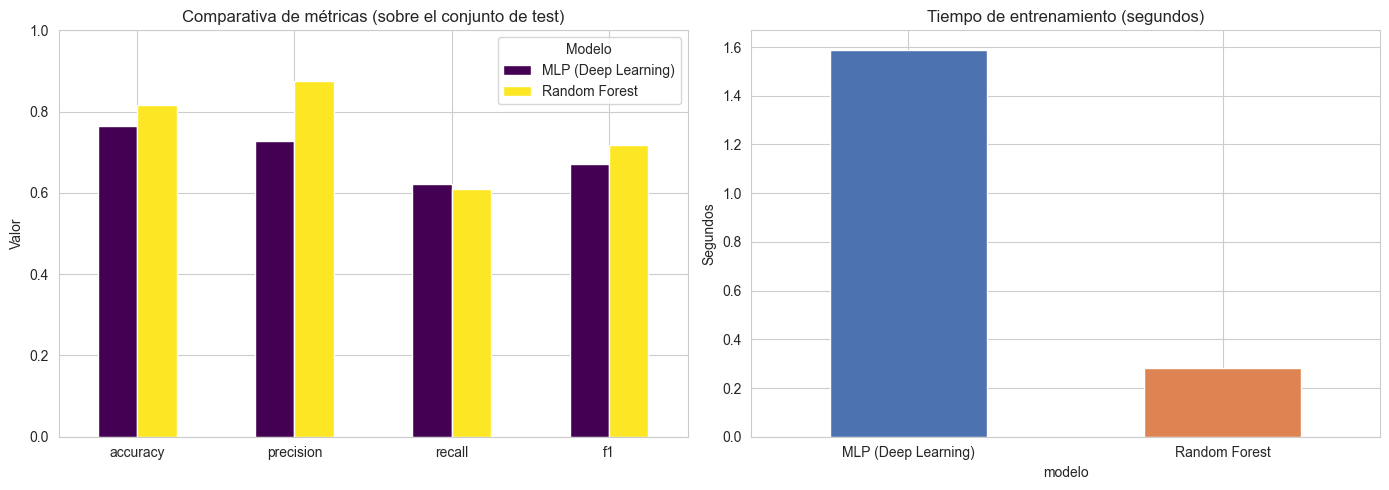

In [24]:
# Lo visualizamos: métricas a la izquierda, tiempos de entrenamiento a la derecha
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metricas = ["accuracy", "precision", "recall", "f1"]
comparativa[metricas].T.plot(kind="bar", ax=axes[0], rot=0, colormap="viridis")
axes[0].set_title("Comparativa de métricas (sobre el conjunto de test)")
axes[0].set_ylabel("Valor")
axes[0].set_ylim(0, 1)
axes[0].legend(title="Modelo")

comparativa["t_entrenamiento_s"].plot(kind="bar", ax=axes[1], rot=0, color=["#4c72b0", "#dd8452"])
axes[1].set_title("Tiempo de entrenamiento (segundos)")
axes[1].set_ylabel("Segundos")

plt.tight_layout()
plt.show()

### ¿Con cuál me quedaría? (decisión argumentada)

**Resultados obtenidos sobre el conjunto de test** (precision y recall referidos a la clase 1,
"sobrevivió"):

| Métrica | MLP (Deep Learning) | Random Forest |
|---|---|---|
| Accuracy | 0,765 | **0,816** |
| Precision | 0,729 | **0,875** |
| Recall | **0,623** | 0,609 |
| F1 | 0,672 | **0,718** |
| Tiempo de entrenamiento | 1,589 s | **0,281 s** |
| Tiempo de predicción | **0,0015 s** | 0,0201 s |
| Tiempo del GridSearch completo | 99,9 s | **4,1 s** |

**Me quedaría con el Random Forest.** Los motivos, por orden de importancia:

**1. Gana en casi todas las métricas.** Saca **5 puntos más de accuracy** (0,816 frente a 0,765) y,
sobre todo, **casi 15 puntos más de precision** (0,875 frente a 0,729). El recall está prácticamente
empatado (0,623 del MLP frente a 0,609 del RF, una diferencia mínima). Es decir: el MLP no compensa
en ningún sitio lo que pierde.

**2. Generaliza mejor.** Este punto es el más interesante de toda la práctica. Si comparamos el
accuracy de la validación cruzada con el del test:

| | Accuracy en CV | Accuracy en test | Caída |
|---|---|---|---|
| MLP | 0,817 | 0,765 | **-5,2 puntos** |
| Random Forest | 0,827 | 0,816 | **-1,2 puntos** |

Los dos modelos parecían casi iguales durante la validación cruzada, pero al enfrentarlos a datos
que no habían visto nunca **el MLP se desinfla mucho más**. El Random Forest se comporta de forma
mucho más consistente, que es justo lo que queremos de un modelo en producción.

**3. Es muchísimo más barato de ajustar.** Optimizar los hiperparámetros del MLP costó **100
segundos** frente a los **4 segundos** del Random Forest: unas **24 veces más**. Y eso que el grid
del RF tenía menos combinaciones porque tampoco necesitaba más.

**4. Es interpretable.** Con `feature_importances_` hemos podido ver directamente que el sexo pesa
casi un 47% en las decisiones del modelo. Del MLP no podemos sacar nada parecido sin recurrir a
técnicas adicionales.

**Un matiz a favor del MLP, para ser justos:** es **13 veces más rápido prediciendo** (0,0015 s
frente a 0,0201 s). Tiene sentido, porque el Random Forest ganador tiene 200 árboles y hay que
recorrerlos todos para cada predicción. Si necesitásemos servir millones de predicciones por segundo,
ese detalle podría llegar a importar. En este problema, evidentemente, no.

---

### La lección de fondo: ¿por qué pierde el Deep Learning?

El resultado no es ninguna sorpresa, y conviene entender el motivo porque es un patrón que se repite:

- **Tenemos muy pocos datos.** 891 filas, de las cuales solo 712 son de entrenamiento. Las redes
  neuronales tienen muchísimos parámetros que ajustar (el MLP ganador, con una capa oculta de 100
  neuronas, tiene del orden de **1.000 pesos** para solo 712 ejemplos) y necesitan **mucho volumen**
  para aprender bien. Con datasets pequeños tienden a sobreajustar, que es exactamente lo que hemos
  visto en el punto 2.
- **Son datos tabulares y estructurados.** El Deep Learning brilla con datos **no estructurados**:
  imágenes, texto, audio, series temporales... En tablas con unas pocas columnas ya procesadas, los
  **ensembles de árboles** (Random Forest, XGBoost, LightGBM) siguen siendo hoy la opción por defecto
  y suelen ganar.

**Conclusión:** el Deep Learning no es "el modelo mejor", es **el modelo adecuado para cierto tipo de
problemas**. Este no es uno de ellos. Ser capaz de reconocerlo es tan importante como saber
construir la red.

---
## 7. Análisis del mejor modelo DL: classification report y matriz de confusión

El enunciado pide, para el **mejor modelo DL obtenido**, mostrar su *classification report* y su
matriz de confusión, comentando el resultado.

In [25]:
# Predicciones del mejor MLP sobre el conjunto de test
y_pred_mlp = mejor_mlp.predict(X_test)

print("=" * 60)
print("CLASSIFICATION REPORT - Mejor modelo DL (MLP)")
print("=" * 60)
print(classification_report(
    y_test, y_pred_mlp,
    target_names=["No sobrevivió (0)", "Sobrevivió (1)"],
    digits=3,
))

CLASSIFICATION REPORT - Mejor modelo DL (MLP)
                   precision    recall  f1-score   support

No sobrevivió (0)      0.783     0.855     0.817       110
   Sobrevivió (1)      0.729     0.623     0.672        69

         accuracy                          0.765       179
        macro avg      0.756     0.739     0.745       179
     weighted avg      0.762     0.765     0.761       179



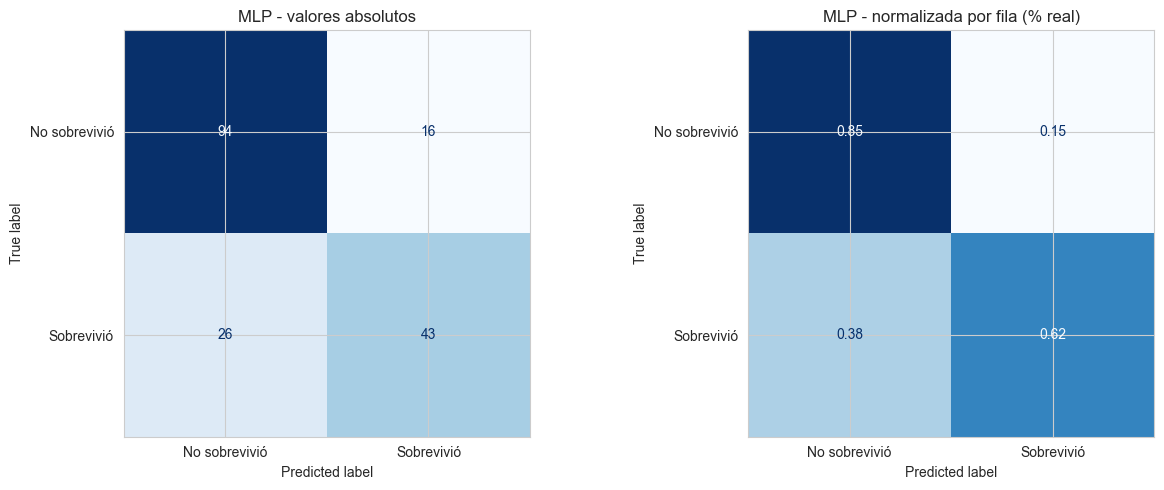

In [26]:
# Matriz de confusión del mejor MLP
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mlp,
    display_labels=["No sobrevivió", "Sobrevivió"],
    cmap="Blues", ax=axes[0], colorbar=False,
)
axes[0].set_title("MLP - valores absolutos")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mlp,
    display_labels=["No sobrevivió", "Sobrevivió"],
    cmap="Blues", ax=axes[1], colorbar=False, normalize="true",
)
axes[1].set_title("MLP - normalizada por fila (% real)")

plt.tight_layout()
plt.show()

### Comentario de los resultados del mejor modelo DL

**Los hiperparámetros ganadores del MLP fueron:** una única capa oculta de 100 neuronas
(`hidden_layer_sizes=(100,)`), activación `relu`, solver `adam`, `alpha=0.01` y
`learning_rate='constant'`.

Es interesante que la topología ganadora sea **la más sencilla de todas las que probamos** (una sola
capa oculta, que además es el valor por defecto de sklearn). Las topologías más profundas, como
`(100, 50, 25)`, no mejoraron el resultado: con tan pocos datos, añadir capas solo sirve para
sobreajustar. También es significativo que ganase el `alpha` más alto del grid (0,01), que es el que
**más regularización** aplica, otra señal de que el modelo necesitaba frenar el sobreajuste.

**Lectura del classification report:**

| Clase | Precision | Recall | F1 | Soporte |
|---|---|---|---|---|
| No sobrevivió (0) | 0,783 | 0,855 | 0,817 | 110 |
| Sobrevivió (1) | 0,729 | 0,623 | 0,672 | 69 |

El modelo es **claramente mejor detectando a los que NO sobrevivieron** (F1 de 0,817) que a los que
sí (F1 de 0,672). La diferencia está sobre todo en el **recall**: acierta el 85,5% de los fallecidos
pero solo el 62,3% de los supervivientes.

**Lectura de la matriz de confusión:**

| | Predicho: No sobrevivió | Predicho: Sobrevivió |
|---|---|---|
| **Real: No sobrevivió** | 94 (aciertos) | 16 (falsos positivos) |
| **Real: Sobrevivió** | **26 (falsos negativos)** | 43 (aciertos) |

El bloque de error más grande son los **26 falsos negativos**: pasajeros que sí sobrevivieron pero a
los que el modelo da por fallecidos. Son bastantes más que los 16 falsos positivos, y explican ese
recall bajo de la clase 1.

**¿Por qué pasa esto?** Por el **desbalanceo del target** que ya detectamos en el EDA: como el 61,6%
de los pasajeros no sobrevivió, el modelo "aprende" que ante la duda es más rentable apostar por la
clase mayoritaria, porque así acierta más veces en promedio. Es un comportamiento muy típico y por eso
no basta con mirar el accuracy global: un 0,765 de accuracy esconde que el modelo funciona bastante
peor con una de las dos clases (el *macro avg* del F1 baja a 0,745).

**¿Cómo se podría mejorar?** Si nos interesase especialmente detectar supervivientes, podríamos:

- Usar **`class_weight='balanced'`** para que el modelo penalice más los errores de la clase
  minoritaria (con `MLPClassifier` no está disponible directamente, pero sí en el Random Forest y en
  la regresión logística).
- **Ajustar el umbral de decisión**: en lugar del 0,5 por defecto, bajarlo con `predict_proba` para
  que sea más "generoso" al predecir supervivencia. Ganaríamos recall a costa de precision.
- **Aplicar remuestreo** (oversampling de la clase minoritaria con SMOTE, por ejemplo).

Como en este problema no hay ninguna razón de negocio para priorizar una clase sobre la otra
(era justo lo que argumentábamos al elegir el accuracy como métrica), lo dejamos así.